<a href="https://colab.research.google.com/github/kavya5cloud/dark-universe-lab/blob/main/notebook%20/%2003_MassMapReconstruction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
#Building a baseline reconstruction model before moving to U-Nets and Diffusion Models.

In [76]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter

import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader,
    random_split
)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: cuda


In [77]:
def generate_sample(size=64):

    mass_map = np.random.normal(
        0,
        1,
        (size,size)
    )

    mass_map = gaussian_filter(
        mass_map,
        sigma=3
    )

    mass_map = (
        mass_map - mass_map.mean()
    ) / mass_map.std()

    fft_mass = np.fft.fft2(mass_map)

    kx = np.fft.fftfreq(size)
    ky = np.fft.fftfreq(size)

    kx, ky = np.meshgrid(kx, ky)

    k2 = kx**2 + ky**2

    k2[0,0] = 1

    potential_fft = fft_mass / k2

    potential_fft[0,0] = 0

    potential = np.real(
        np.fft.ifft2(
            potential_fft
        )
    )

    gy, gx = np.gradient(
        potential
    )

    gxx = np.gradient(
        gx,
        axis=1
    )

    gyy = np.gradient(
        gy,
        axis=0
    )

    gxy = np.gradient(
        gx,
        axis=0
    )

    gamma1 = 0.5 * (gxx - gyy)

    gamma2 = gxy

    gamma1 += np.random.normal(
        0,
        0.05,
        gamma1.shape
    )

    gamma2 += np.random.normal(
        0,
        0.05,
        gamma2.shape
    )

    shear = np.stack(
        [gamma1, gamma2],
        axis=0
    )

    return shear, mass_map

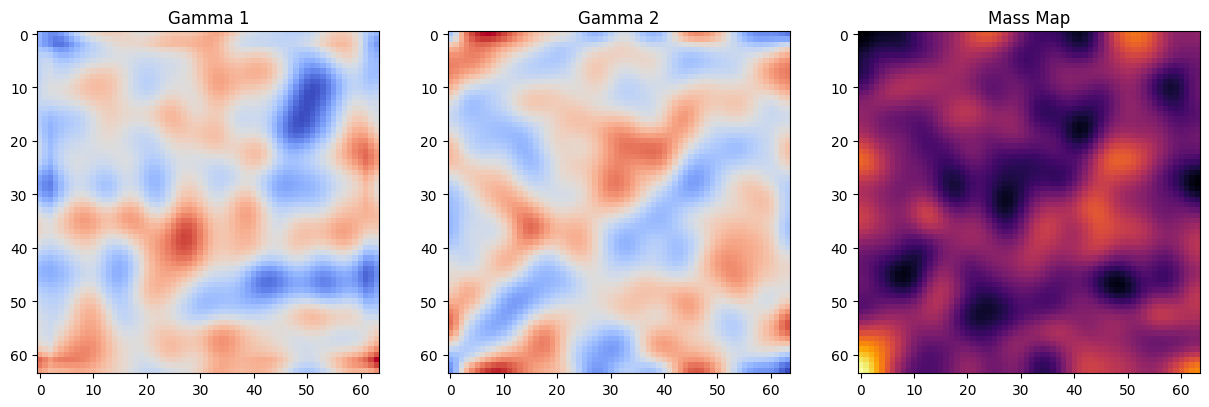

In [78]:
shear, mass = generate_sample()

fig, ax = plt.subplots(
    1,
    3,
    figsize=(15,5)
)

ax[0].imshow(
    shear[0],
    cmap="coolwarm"
)

ax[0].set_title("Gamma 1")

ax[1].imshow(
    shear[1],
    cmap="coolwarm"
)

ax[1].set_title("Gamma 2")

ax[2].imshow(
    mass,
    cmap="inferno"
)

ax[2].set_title("Mass Map")

plt.show()

In [79]:
N = 1000

X = []
Y = []

for _ in range(N):

    shear, mass = generate_sample()

    X.append(shear)

    Y.append(mass)

X = np.array(X)

Y = np.array(Y)

print(X.shape)
print(Y.shape)

(1000, 2, 64, 64)
(1000, 64, 64)


In [80]:
X_mean = X.mean()

X_std = X.std()

X = (
    X - X_mean
) / X_std

print(X.mean())
print(X.std())

-1.603925325888156e-17
1.0000000000000007


In [81]:
class LensingDataset(Dataset):

    def __init__(self,X,Y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.Y = torch.tensor(
            Y,
            dtype=torch.float32
        ).unsqueeze(1)

    def __len__(self):

        return len(self.X)

    def __getitem__(self,idx):

        return (
            self.X[idx],
            self.Y[idx]
        )

In [82]:
dataset = LensingDataset(
    X,
    Y
)

train_size = int(
    0.8*len(dataset)
)

val_size = len(dataset)-train_size

train_ds, val_ds = random_split(
    dataset,
    [train_size,val_size]
)

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=32
)

In [83]:
class MassCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(
                2,
                32,
                3,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv2d(
                32,
                64,
                3,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv2d(
                64,
                64,
                3,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv2d(
                64,
                32,
                3,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv2d(
                32,
                1,
                3,
                padding=1
            )
        )

    def forward(self,x):

        return self.net(x)

In [84]:
model = MassCNN().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [85]:
epochs = 50

train_losses = []

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for x,y in train_loader:

        x = x.to(device)

        y = y.to(device)

        pred = model(x)

        loss = criterion(
            pred,
            y
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = (
        running_loss /
        len(train_loader)
    )

    train_losses.append(
        epoch_loss
    )

    print(
        f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.6f}"
    )

Epoch 1/50 | Loss: 0.646768
Epoch 2/50 | Loss: 0.415873
Epoch 3/50 | Loss: 0.368359
Epoch 4/50 | Loss: 0.337383
Epoch 5/50 | Loss: 0.317775
Epoch 6/50 | Loss: 0.309596
Epoch 7/50 | Loss: 0.290722
Epoch 8/50 | Loss: 0.274821
Epoch 9/50 | Loss: 0.292741
Epoch 10/50 | Loss: 0.280148
Epoch 11/50 | Loss: 0.247489
Epoch 12/50 | Loss: 0.235292
Epoch 13/50 | Loss: 0.227915
Epoch 14/50 | Loss: 0.220632
Epoch 15/50 | Loss: 0.213526
Epoch 16/50 | Loss: 0.209433
Epoch 17/50 | Loss: 0.205740
Epoch 18/50 | Loss: 0.199864
Epoch 19/50 | Loss: 0.197279
Epoch 20/50 | Loss: 0.192406
Epoch 21/50 | Loss: 0.189130
Epoch 22/50 | Loss: 0.189530
Epoch 23/50 | Loss: 0.186907
Epoch 24/50 | Loss: 0.184007
Epoch 25/50 | Loss: 0.180797
Epoch 26/50 | Loss: 0.178724
Epoch 27/50 | Loss: 0.177215
Epoch 28/50 | Loss: 0.173812
Epoch 29/50 | Loss: 0.171268
Epoch 30/50 | Loss: 0.169996
Epoch 31/50 | Loss: 0.168699
Epoch 32/50 | Loss: 0.168647
Epoch 33/50 | Loss: 0.166371
Epoch 34/50 | Loss: 0.166742
Epoch 35/50 | Loss: 0.1

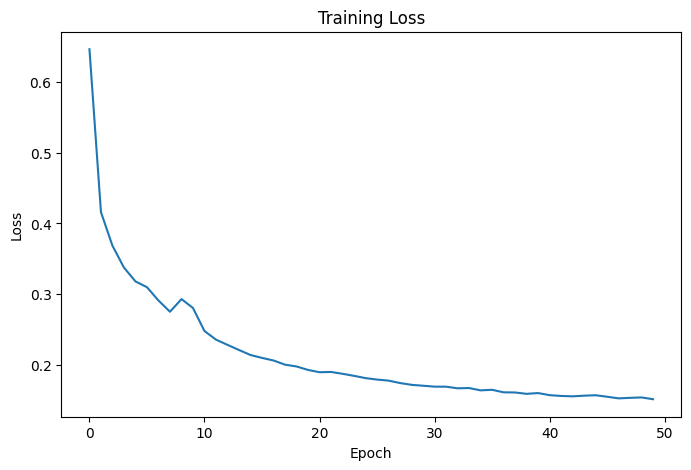

In [86]:
plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.show()

In [87]:
model.eval()

x,y = next(
    iter(val_loader)
)

with torch.no_grad():

    pred = model(
        x.to(device)
    )

pred = pred.cpu().numpy()

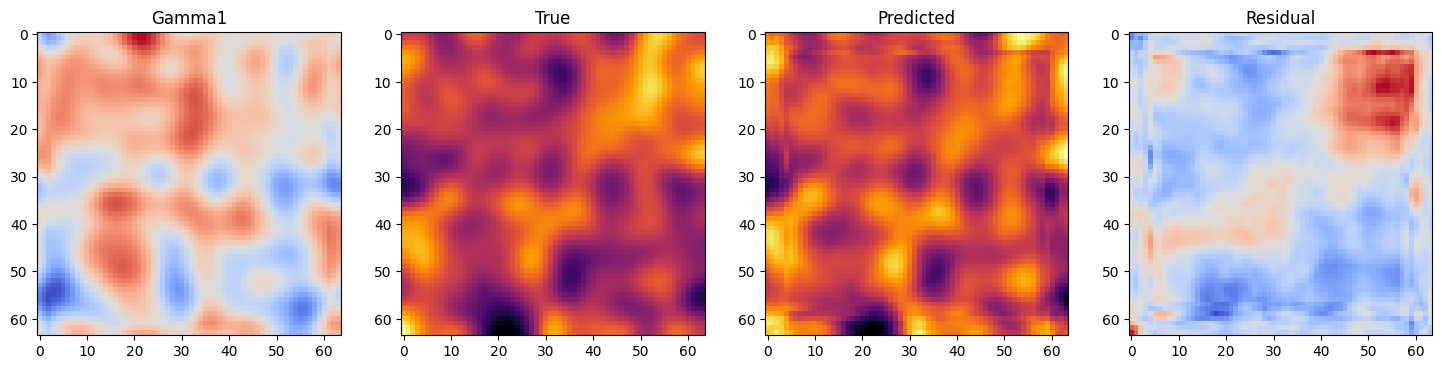

In [88]:
idx = 0

fig, ax = plt.subplots(
    1,
    4,
    figsize=(18,5)
)

ax[0].imshow(
    x[idx,0],
    cmap="coolwarm"
)
ax[0].set_title("Gamma1")

ax[1].imshow(
    y[idx,0],
    cmap="inferno"
)
ax[1].set_title("True")

ax[2].imshow(
    pred[idx,0],
    cmap="inferno"
)
ax[2].set_title("Predicted")

residual = (
    y[idx,0].numpy() -
    pred[idx,0]
)

ax[3].imshow(
    residual,
    cmap="coolwarm"
)
ax[3].set_title("Residual")

plt.show()

In [89]:
true_map = y[idx,0].numpy().flatten()

pred_map = pred[idx,0].flatten()

corr = np.corrcoef(
    true_map,
    pred_map
)[0,1]

print("Correlation:", corr)

Correlation: 0.8940201424461429
